# Auto Regression Hands-On

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import important libraries
import pandas as pd
import yfinance as yf
import datetime as dt
from nsepy import get_history as gh
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg # Import AutoReg model
from stockFunctions import rmsemape
from stockFunctions import graph
from stockFunctions import conversionSingle

In [3]:
# Dataset collection
stock_symbol = "RELIANCE.NS"
Stk_data =yf.download(stock_symbol, start = "2023-01-01", end = "2023-07-01")
Stk_data.info() # Check the quality of dataset

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 122 entries, 2023-01-02 to 2023-06-30
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   122 non-null    float64
 1   (High, RELIANCE.NS)    122 non-null    float64
 2   (Low, RELIANCE.NS)     122 non-null    float64
 3   (Open, RELIANCE.NS)    122 non-null    float64
 4   (Volume, RELIANCE.NS)  122 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 5.7 KB


In [4]:
# Check parameters and values in the dataset
Stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1170.477905,1171.886546,1157.891121,1158.709022,5316175
2023-01-03,1161.912476,1169.160126,1157.709389,1165.547659,7658932
2023-01-04,1144.418213,1163.730055,1142.350684,1161.889687,9264891
2023-01-05,1142.373413,1152.529209,1137.806748,1146.667484,13637099
2023-01-06,1152.756470,1157.777578,1144.304744,1148.098940,6349597
...,...,...,...,...,...
2023-06-23,1142.691650,1151.166093,1141.442022,1149.121279,6628570
2023-06-26,1133.967163,1142.986912,1130.854571,1139.170000,12641159


In [5]:
# Consideration of important parameters of the dataset
Stk_data = Stk_data[["Close", "High", "Low", "Open"]]
Stk_data

Price,Close,High,Low,Open
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,
2023-01-02,1170.477905,1171.886546,1157.891121,1158.709022
2023-01-03,1161.912476,1169.160126,1157.709389,1165.547659
2023-01-04,1144.418213,1163.730055,1142.350684,1161.889687
2023-01-05,1142.373413,1152.529209,1137.806748,1146.667484
2023-01-06,1152.756470,1157.777578,1144.304744,1148.098940
...,...,...,...,...
2023-06-23,1142.691650,1151.166093,1141.442022,1149.121279
2023-06-26,1133.967163,1142.986912,1130.854571,1139.170000


In [6]:
# Separate the functions to carry out univariate analysis
Column = "Close"

In [7]:
# Model creation
MMS = MinMaxScaler()
Data1 = MMS.fit_transform(Stk_data[[Column]])
print("Length of data is:", Data1.shape)

Length of data is: (122, 1)


In [8]:
# Training of model
Training_size = round(len(Data1)*0.8) # Here 0.8 is a playable parameter. The developer can use different values to get an optimised output.
print(Training_size)
X_train = Data1[:Training_size]
X_test = Data1[Training_size:]
print (f"The length of X_train is: {X_train.shape}")
print (f"The length of X_test is: {X_test.shape}")
# Note: In the case of TSA, the input and output are the same. This is because TSA is univariate analysis
Y_train = X_train
Y_test = X_test

98
The length of X_train is: (98, 1)
The length of X_test is: (24, 1)


In [9]:
# Model optimisation
Trends = ['n', 't', 'c', 'ct']
Lags = [1,2,3,4]
for i in Lags: 
    # To print i
    for td in Trends: 
        # To print td
        Model = AutoReg(X_train, lags=i, trend=td)
        Model_fit = Model.fit()
        # Making a prediction
        Y_pred = Model_fit.predict(len(X_train), len(Data1)-1)
        print ("Lag ={}, Trend ={}".format(i,td))
        rmsemape (Y_test, Y_pred)
        print ("*********")
# Note: A lower value is preferred as the best model

Lag =1, Trend =n
RMSE-Testset: 0.2070622692137381
maPe-Testset: 0.20437380493127835
*********
Lag =1, Trend =t
RMSE-Testset: 0.08729798128150143
maPe-Testset: 0.10202890230618615
*********
Lag =1, Trend =c
RMSE-Testset: 0.2438776896784907
maPe-Testset: 0.2468871471001404
*********
Lag =1, Trend =ct
RMSE-Testset: 0.0780838891482021
maPe-Testset: 0.08950078076933499
*********
Lag =2, Trend =n
RMSE-Testset: 0.19783582741317518
maPe-Testset: 0.1946828996758223
*********
Lag =2, Trend =t
RMSE-Testset: 0.09111694062756893
maPe-Testset: 0.1054548783664883
*********
Lag =2, Trend =c
RMSE-Testset: 0.24683180028473015
maPe-Testset: 0.24965357751554393
*********
Lag =2, Trend =ct
RMSE-Testset: 0.08151898261178657
maPe-Testset: 0.09038133149180953
*********
Lag =3, Trend =n
RMSE-Testset: 0.17269156152342857
maPe-Testset: 0.17003054712795276
*********
Lag =3, Trend =t
RMSE-Testset: 0.09011835757649911
maPe-Testset: 0.10445730250022998
*********
Lag =3, Trend =c
RMSE-Testset: 0.23169398253952023
maP

In [10]:
len(Y_pred)

24

In [11]:
# It is noted that for Lag =1, Trend =ct, we got the lowest value for RMSE and MAPE
td = 'ct'
i = 1
Model = AutoReg(X_train, lags=i, trend=td)
Model_fit = Model.fit()
Y_pred = Model_fit.predict(len(X_train), len(Data1)-1)
print ("Lag ={}, Trend ={}".format(i,td))
rmsemape (Y_test, Y_pred)
print ("*********")

Lag =1, Trend =ct
RMSE-Testset: 0.0780838891482021
maPe-Testset: 0.08950078076933499
*********


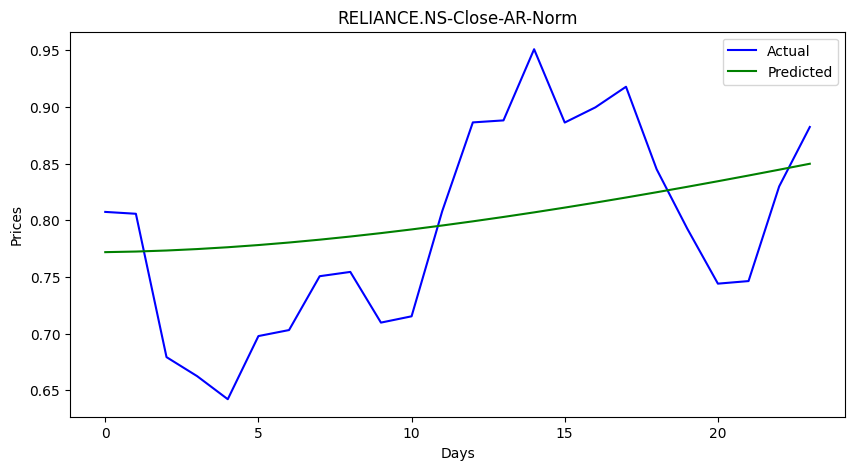

In [12]:
# Visualise model output
graph(Y_test, Y_pred, "Actual", "Predicted", "RELIANCE.NS-Close-AR-Norm", "Days", "Prices")

In [13]:
# Checking length of output
len(Data1)

122

In [14]:
# Check the test sample
Y_test

array([[0.80735663],
       [0.80571306],
       [0.67918014],
       [0.66236881],
       [0.64201767],
       [0.69776273],
       [0.70307108],
       [0.7506003 ],
       [0.75439207],
       [0.7096447 ],
       [0.71520637],
       [0.80798825],
       [0.88636033],
       [0.88813023],
       [0.95095421],
       [0.88623468],
       [0.8996339 ],
       [0.91783616],
       [0.84502508],
       [0.79256785],
       [0.74402735],
       [0.74630323],
       [0.82985732],
       [0.88231591]])

In [15]:
# Actual value calculation
TrueValue_A = conversionSingle(Y_test, [Column])
Stockprice_Value = MMS.inverse_transform(TrueValue_A)
Actual_Stockprice_Value = conversionSingle(Stockprice_Value, [Column])

In [16]:
# Predicted value calculation
TrueValue_P = conversionSingle(Y_pred, [Column])
Stockprice_Value = MMS.inverse_transform(TrueValue_P)
Predicted_Stockprice_Value = conversionSingle(Stockprice_Value, [Column])

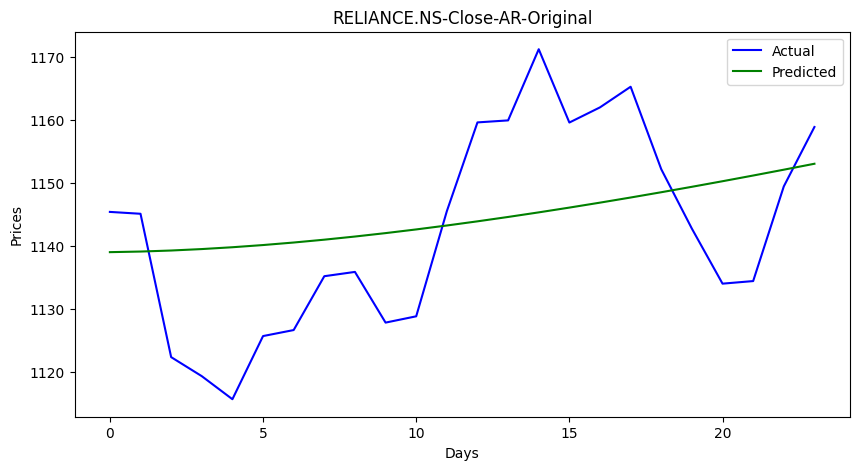

In [17]:
# Visualisation after calculation of actual and predicted values
graph(Actual_Stockprice_Value, Predicted_Stockprice_Value, "Actual", "Predicted", "RELIANCE.NS-Close-AR-Original", "Days", "Prices")

In [18]:
# Determine the RMS and MAP values for actual and predicted
rmsemape (Actual_Stockprice_Value, Predicted_Stockprice_Value)

RMSE-Testset: 14.034506755355004
maPe-Testset: 0.010894766947519528


In [19]:
# Farcasting for subsequent three days
Forecast = Model_fit.predict(len(Data1), len(Data1)+3)
Forecast 

array([0.85520241, 0.86063412, 0.86615043, 0.87174618])

In [20]:
# Carryout forecasting 
FTest_NormalTable = conversionSingle(Forecast , ["Closeforce"])
Stockprice_Original = MMS.inverse_transform(FTest_NormalTable)
Stockprice_Forcast = conversionSingle(Stockprice_Original, ["Closeforce"])
Stockprice_Forcast

,Closeforce
0,1153.949353
1,1154.925628
2,1155.91711
3,1156.922868


In [21]:
# Saving the final forecasted values
Stockprice_Forcast.to_csv("CloseAR_Forcast.csv", index = False)